In [1]:
# from src.MPOptoClass import *
from src.utils.gen_utils import *
from src.utils.filters import *
from src.helpers.experiment import *
from src.wiener_filter import *
from src.modeller import *
from src.MPRecordClass import *
from src.ReachingClass import *
from src.analysis import *
import scipy
import copy
import time
import mat73 
import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
import random
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from itertools import permutations, compress, product




%load_ext autoreload 
%autoreload 2
%matplotlib widget

In [2]:
session_path = '../data/co/co9/co9_12122023'
session = MPOptoClass(session_path)

love


# lets double check if a stim only model works

In [3]:
nlags = 20
binsize=5
pre = nlags * binsize
post=50
num_PCs=20

laser_bounds = adjustBounds(session.laser['laser_bounds'], pre, post)
train_lasers, test_lasers = train_test_split(laser_bounds, train_size=0.8, random_state=1)
ctrl_bounds = adjustBounds(session.laser['ctrl_bounds'], pre, post)

(X, _), X_PCs = session.format_nlags_PCA(train_lasers, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
(_, Y) = session.transformat_smooth(X_PCs, bounds=train_lasers, binsize=binsize, nlags=nlags, num_PCs=num_PCs, sigma=5, smooth_type='future')
Y=Y[:,num_PCs:]
(X_ltest, _) = session.transformat(X_PCs, bounds=test_lasers, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
(_, Y_ltest) = session.transformat_smooth(X_PCs, bounds=test_lasers, binsize=binsize, nlags=nlags, num_PCs=num_PCs, sigma=5, smooth_type='future')

Y_ltest=Y_ltest[:,num_PCs:]
(X_lctrl, _) = session.transformat(X_PCs, bounds=ctrl_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
(_, Y_lctrl) = session.transformat_smooth(X_PCs, bounds=ctrl_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs, sigma=5, smooth_type='future')
Y_lctrl=Y_lctrl[:,num_PCs:]

In [35]:
h_laser = train_wiener_filter(X, Y, c=(2,5))
yhat_laser = test_wiener_filter(X_ltest, h_laser)
yhat_ctrl = test_wiener_filter(X_lctrl, h_laser)

laser = []
laser.append(weighted_r2(Y_ltest, yhat_laser))
laser.append(weighted_r2(Y_lctrl, yhat_ctrl))



None
best_c: 464.15888336127773


In [36]:
omitLaserBounds = omitBoundInBounds(session.climbing_bounds, test_lasers)
omitLaserBounds = omitBoundInBounds(omitLaserBounds, ctrl_bounds)
omitLaserBounds = minimumBoundSize(omitLaserBounds, min_size=pre+post)
sw = session.getSWs(bigBound = omitLaserBounds, smallBound=train_lasers, sw_weight=100, binsize=5, nlags=20)
(X, _), X_PCs = session.format_nlags_PCA(bounds=omitLaserBounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
(_, Y) = session.transformat_smooth(X_PCs, bounds=omitLaserBounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs, sigma=5, smooth_type='future')
Y=Y[:,num_PCs:]
(X_btest, _) = session.transformat(X_PCs, bounds=test_lasers, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
(_, Y_btest) = session.transformat_smooth(X_PCs, bounds=test_lasers, binsize=binsize, nlags=nlags, num_PCs=num_PCs, sigma=5, smooth_type='future')

Y_btest=Y_btest[:,num_PCs:]
(X_bctrl, _) = session.transformat(X_PCs, bounds=ctrl_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
(_, Y_bctrl) = session.transformat_smooth(X_PCs, bounds=ctrl_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs, sigma=5, smooth_type='future')
Y_bctrl=Y_bctrl[:,num_PCs:]



In [37]:
h_both = train_wiener_filter(X, Y, c=(2,5), sw=sw)
yhat_laser = test_wiener_filter(X_btest, h_both)
yhat_ctrl = test_wiener_filter(X_bctrl, h_both)

both = []
both.append(weighted_r2(Y_btest, yhat_laser))
both.append(weighted_r2(Y_bctrl, yhat_ctrl))

[1. 1. 1. ... 1. 1. 1.]
best_c: 46415.888336127726


In [38]:
omitLaserBounds = omitBoundInBounds(session.climbing_bounds, laser_bounds)
omitLaserBounds = omitBoundInBounds(omitLaserBounds, ctrl_bounds)
omitLaserBounds = minimumBoundSize(omitLaserBounds, min_size=pre+post)
(X, _), X_PCs = session.format_nlags_PCA(bounds=omitLaserBounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
(_, Y) = session.transformat_smooth(X_PCs, bounds=omitLaserBounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs, sigma=5, smooth_type='future')
Y=Y[:,num_PCs:]
(X_ctest, _) = session.transformat(X_PCs, bounds=test_lasers, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
(_, Y_ctest) = session.transformat_smooth(X_PCs, bounds=test_lasers, binsize=binsize, nlags=nlags, num_PCs=num_PCs, sigma=5, smooth_type='future')

Y_ctest=Y_ctest[:,num_PCs:]
(X_cctrl, _) = session.transformat(X_PCs, bounds=ctrl_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
(_, Y_cctrl) = session.transformat_smooth(X_PCs, bounds=ctrl_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs, sigma=5, smooth_type='future')
Y_cctrl=Y_cctrl[:,num_PCs:]

In [46]:
h_climb = train_wiener_filter(X, Y, c=(2,5))
yhat_laser = test_wiener_filter(X_ctest, h_climb)
yhat_ctrl = test_wiener_filter(X_cctrl, h_climb)
print(weighted_r2(Y_ctest, yhat_laser))
print(weighted_r2(Y_cctrl, yhat_ctrl))

climbing = []
climbing.append(weighted_r2(Y_ctest, yhat_laser))
climbing.append(weighted_r2(Y_cctrl, yhat_ctrl))

None
best_c: 10000.0
-0.2841289782611262
-0.042291754426409735


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


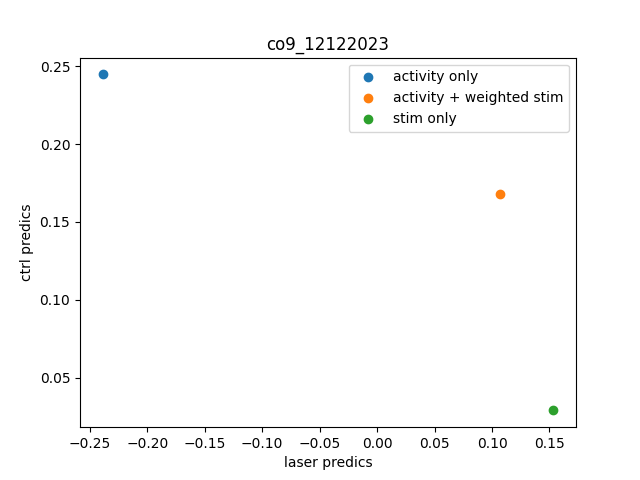

In [47]:
fig, ax = plt.subplots()
ax.set_ylabel('ctrl predics')
ax.set_xlabel('laser predics')
ax.set_title('co9_12122023')
ax.scatter(climbing[0], climbing[1], label='activity only')
ax.scatter(both[0], both[1], label='activity + weighted stim')
ax.scatter(laser[0], laser[1], label='stim only')
ax.legend()

# lets get some intuition about weights 

## how does the drive change on laser vs cntrls

In [52]:
l_test = np.vstack((X_lctrl[:330,:], X_ltest))
b_test = np.vstack((X_bctrl[:330,:], X_btest))
c_test = np.vstack((X_cctrl[:330,:], X_ctest))

yl_test = np.vstack((Y_lctrl[:330,:], Y_ltest))
yb_test = np.vstack((Y_bctrl[:330,:], Y_btest))
yc_test = np.vstack((Y_cctrl[:330,:], Y_ctest))

temp = test_wiener_filter(l_test, h_laser)
l_score = weighted_r2(yl_test, temp)

temp = test_wiener_filter(b_test, h_both)
b_score = weighted_r2(yb_test, temp)

temp = test_wiener_filter(c_test, h_climb)
c_score = weighted_r2(yc_test, temp)

all_scores = [l_score, b_score, c_score]



lic, lir = session.relative_input(h_laser, l_test, nlags=20, num_CFA=20)
laser_ratio = np.log10(lic/lir)
bic, bir= session.relative_input(h_both, b_test, nlags=20, num_CFA=20)
both_ratio = np.log10(bic/bir)
cic, cir = session.relative_input(h_climb, c_test, nlags=20, num_CFA=20)
climb_ratio = np.log10(cic/cir)

all_ratios = [laser_ratio, both_ratio, climb_ratio]

In [58]:
c_score

-0.09466468897489608

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


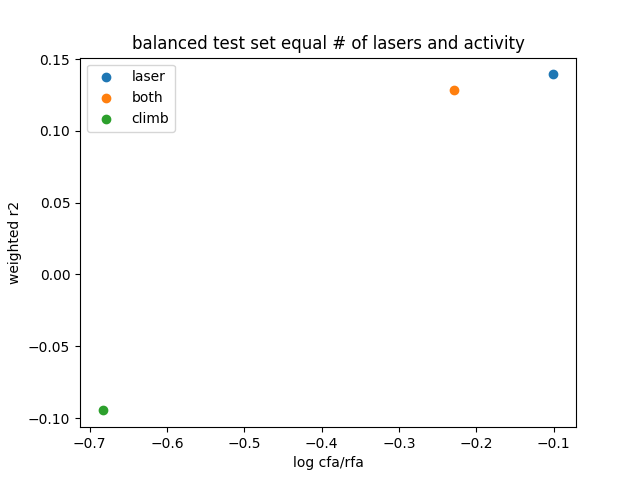

In [65]:
fig, ax = plt.subplots()
colors=['tab:blue', 'tab:orange', 'tab:green']
labels = ['laser', 'both', 'climb']
for idx in np.arange(3):
    ax.scatter(all_ratios[idx], all_scores[idx], c=colors[idx], label=labels[idx])
ax.set_title('balanced test set equal # of lasers and activity')
ax.set_xlabel('log cfa/rfa')
ax.set_ylabel('weighted r2')
ax.legend()

In [17]:
h_laser.shape

(801, 20)

# train lasers check

In [7]:
new_train_lasers[0][1] - new_train_lasers[0][0]

175

In [9]:
check0 = bounds2Logical(session.climbing_bounds)
check1 = bounds2Logical(new_train_lasers)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


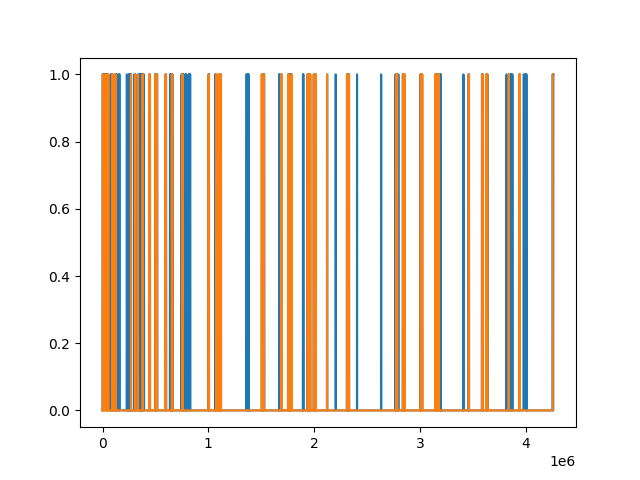

In [11]:
fig, ax = plt.subplots()
ax.plot(check0)
ax.plot(check1)

In [8]:
train_lasers[0][1] - train_lasers[0][0]

175

In [6]:
num_trials = len(train_lasers)
new_train_lasers = session.generate_new_ctrls(num_trials, pre=pre, post=post)

omitLaserBounds = omitBoundInBounds(session.climbing_bounds, test_lasers)
omitLaserBounds = omitBoundInBounds(omitLaserBounds, ctrl_bounds)
omitLaserBounds = minimumBoundSize(omitLaserBounds, min_size=pre+post)
sw = session.getSWs(bigBound = omitLaserBounds, smallBound=new_train_lasers, sw_weight=100, binsize=5, nlags=20)
(X, _), X_PCs = session.format_nlags_PCA(bounds=omitLaserBounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
(_, Y) = session.transformat_smooth(X_PCs, bounds=omitLaserBounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs, sigma=5, smooth_type='future')
Y=Y[:,num_PCs:]
(X_btest, _) = session.transformat(X_PCs, bounds=test_lasers, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
(_, Y_btest) = session.transformat_smooth(X_PCs, bounds=test_lasers, binsize=binsize, nlags=nlags, num_PCs=num_PCs, sigma=5, smooth_type='future')

Y_btest=Y_btest[:,num_PCs:]
(X_bctrl, _) = session.transformat(X_PCs, bounds=ctrl_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
(_, Y_bctrl) = session.transformat_smooth(X_PCs, bounds=ctrl_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs, sigma=5, smooth_type='future')
Y_bctrl=Y_bctrl[:,num_PCs:]



In [66]:
l_test = np.vstack((X_lctrl, X_ltest))
b_test = np.vstack((X_bctrl, X_btest))
c_test = np.vstack((X_cctrl, X_ctest))

yl_test = np.vstack((Y_lctrl, Y_ltest))
yb_test = np.vstack((Y_bctrl, Y_btest))
yc_test = np.vstack((Y_cctrl, Y_ctest))

temp = test_wiener_filter(l_test, h_laser)
l_score = weighted_r2(yl_test, temp)

temp = test_wiener_filter(b_test, h_both)
b_score = weighted_r2(yb_test, temp)

temp = test_wiener_filter(c_test, h_climb)
c_score = weighted_r2(yc_test, temp)

all_scores = [l_score, b_score, c_score]



lic, lir = session.relative_input(h_laser, l_test, nlags=20, num_CFA=20)
laser_ratio = np.log10(lic/lir)
bic, bir= session.relative_input(h_both, b_test, nlags=20, num_CFA=20)
both_ratio = np.log10(bic/bir)
cic, cir = session.relative_input(h_climb, c_test, nlags=20, num_CFA=20)
climb_ratio = np.log10(cic/cir)

all_ratios = [laser_ratio, both_ratio, climb_ratio]

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


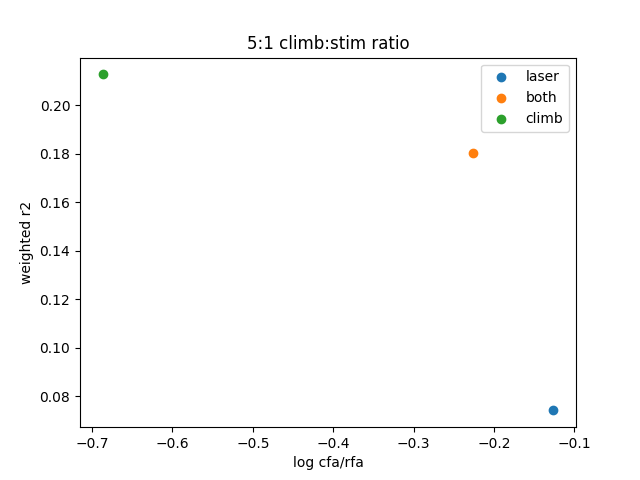

In [69]:
fig, ax = plt.subplots()
colors=['tab:blue', 'tab:orange', 'tab:green']
labels = ['laser', 'both', 'climb']
for idx in np.arange(3):
    ax.scatter(all_ratios[idx], all_scores[idx], c=colors[idx], label=labels[idx])
ax.set_title('5:1 climb:stim ratio')
ax.set_xlabel('log cfa/rfa')
ax.set_ylabel('weighted r2')
ax.legend()

In [67]:
X_lctrl.shape

(1680, 800)

# lets shuffle bounds so that isn't amplifying lasers anymore

In [4]:
bounds = session.climbing_bounds

In [6]:
boundsLogical = bounds2Logical(bounds)

In [15]:
allowed = np.where(boundsLogical==1)[0]

In [19]:
samples = np.sort(np.random.choice(allowed, size=100, replace=False))

In [30]:
newBounds = np.zeros((samples[-1]+1))
newBounds[samples] = 1

In [3]:
output = pload('../picklejar/ctrlSweepRegsSW_20nlag_50post.pickle')
asymps = pload('../picklejar/ctrlSweepRegsSWasymps_20nlag_50post.pickle')
session_path = '../data/co/co9/co9_12122023'
session = MPOptoClass(session_path)

love


In [11]:
this_session

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 ((array([[-1.77834605e-03, -1.03501818e-03, -5.08124079e-04, ...,
           -4.03097710e-04, -4.51846712e-04,  2.66170253e-04],
          [-2.00813199e-04, -3.40003513e-04,  8.62307462e-04, ...,
           -3.30891197e-04, -1.61730846e-05,  1.51888246e-04],
          [ 7.12196685e-04,  1.05170390e-03, -2.55632419e-04, ...,
            8.84408470e-04,  2.59173106e-04, -2.03031384e-04],
          ...,
          [ 3.38285626e-02,  7.02617982e-03,  4.61965287e-03, ...,
            3.39277469e-03, -3.76383453e-03,  7.71451618e-03],
          [ 1.35306737e-02,  1.47044655e-02, -1.34652749e-02, ...,
           -4.76145951e-03, -3.25784448e-02, -1.48865374e-02],
          [-2.33729485e-02, -7.16924473e-03, -1.05944528e-02, ...,
            2.80446199e-03, -1.16726762e-02, -1.49518769e-02]]),
   -1.2292028714110994,
   -1.1382335076523407,
   -1.2481850593001276,
   0.1918824860811366,
   0.292

In [4]:
session_lr2s = []
session_cr2s=[]

session_sw_lr2s = []
session_sw_cr2s=[]


session_ratios=[]
session_sw_ratios=[]

session_iratios = []
session_sw_iratios = []


laser_asymps = []
ctrl_asymps = []

for idx, this_session in enumerate(output): 
    if this_session==0:
        continue
    if this_session[0][3] == 'cfa':
        continue
    run_lr2s=[]
    run_cr2s=[]
    run_ratios=[]
    run_iratios = []

    run_sw_lr2s=[]
    run_sw_cr2s=[]
    run_sw_ratios=[]
    run_sw_iratios=[]
    for run in this_session:
        
        h=run[0][0]
        run_ratios.append(run[0][1])
        run_iratios.append((run[0][2], run[0][3]))
        run_lr2s.append(run[0][4])
        run_cr2s.append(run[0][5])
        
         
        h_sw=run[1][0]
        run_sw_ratios.append(run[1][1])
        run_sw_iratios.append((run[1][2], run[1][3]))
        run_sw_lr2s.append(run[1][4])
        run_sw_cr2s.append(run[1][5])

        
    session_lr2s.append(run_lr2s)
    session_cr2s.append(run_cr2s)
    session_ratios.append(run_ratios)
    
    session_sw_lr2s.append(run_sw_lr2s)
    session_sw_cr2s.append(run_sw_cr2s)
    session_sw_ratios.append(run_sw_ratios)
    
    session_iratios.append(run_iratios)
    session_sw_iratios.append(run_sw_iratios)
    
    laser_asymps.append((asymps[idx][0][0], asymps[idx][1][0]))
    ctrl_asymps.append((asymps[idx][0][1], asymps[idx][1][1]))
    

session_iratios = np.array(session_iratios)
session_sw_iratios = np.array(session_sw_iratios)

TypeError: 'int' object is not subscriptable

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


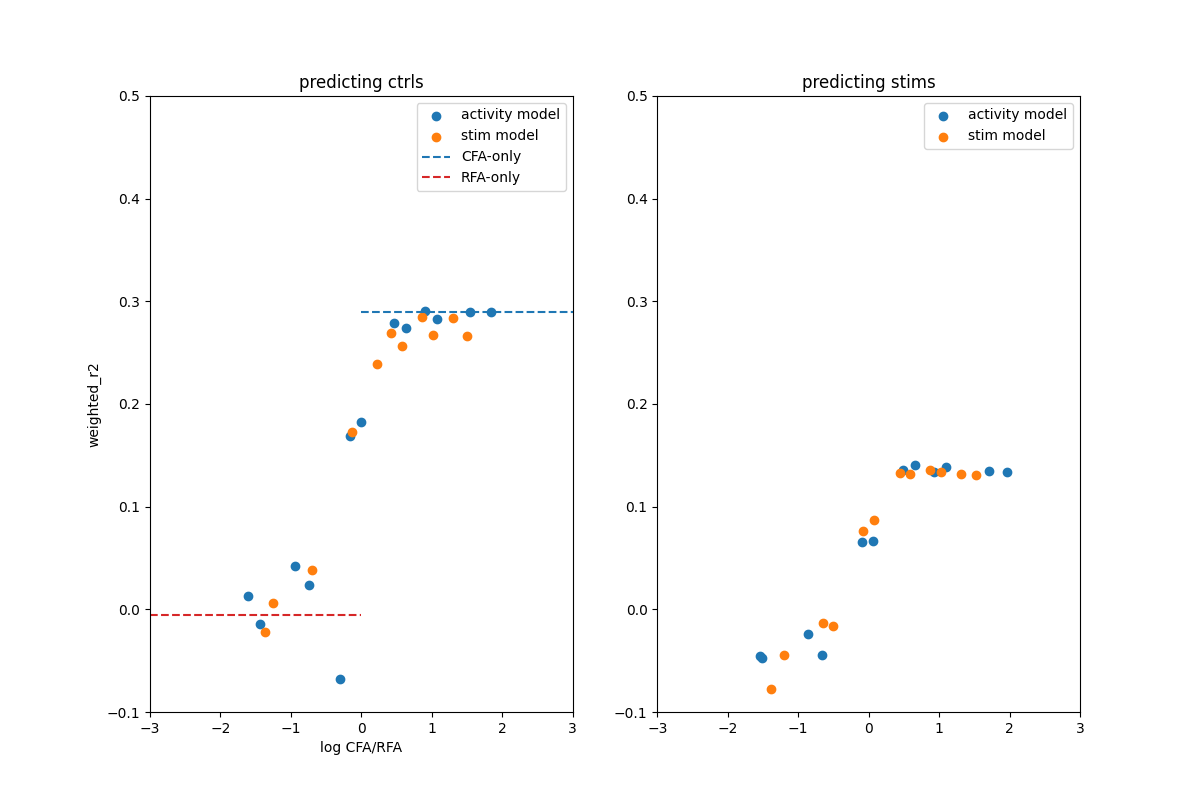

In [17]:
session_num = 4

#ratio_keep, cr2_keep, edges = get_top_models(np.array(session_ratios[session_num]), np.array(session_cr2s[session_num]))
ratio_keep, cr2_keep, edges = get_top_models(session_iratios[session_num,:,0], np.array(session_cr2s[session_num]))
ratio_sw_keep, cr2_sw_keep, _ = get_top_models(session_sw_iratios[session_num,:,0], np.array(session_sw_cr2s[session_num]), edges=edges)

ratio_lkeep, lr2_keep, edges = get_top_models(session_iratios[session_num,:,1], np.array(session_lr2s[session_num]))
ratio_sw_lkeep, lr2_sw_keep, _ = get_top_models(session_sw_iratios[session_num,:,1], np.array(session_sw_lr2s[session_num]), edges=edges)

fig, ax = plt.subplots(ncols=2)
ax[0].scatter(ratio_keep, cr2_keep, color='tab:blue', label='activity model')
ax[0].scatter(ratio_sw_keep, cr2_sw_keep, color='tab:orange', label='stim model')
ax[0].axhline(ctrl_asymps[session_num][0], xmin=.5,color='tab:blue', linestyle='--', label='CFA-only')
ax[0].axhline(ctrl_asymps[session_num][1], xmax=.5,color='tab:red', linestyle='--', label='RFA-only')
ax[0].set_xlim(-3,3)
ax[0].set_ylim(-.1, .5)
ax[0].set_title('predicting ctrls')
ax[0].set_ylabel('weighted_r2')
ax[0].set_xlabel('log CFA/RFA')
ax[0].legend()

ax[1].scatter(ratio_lkeep, lr2_keep, color='tab:blue', label='activity model')
ax[1].scatter(ratio_sw_lkeep, lr2_sw_keep, color='tab:orange', label='stim model')
ax[1].set_xlim(-3,3)
ax[1].set_ylim(-.1, .5)
ax[1].set_title('predicting stims')
ax[1].legend()

fig.set_figheight(8)
fig.set_figwidth(12)


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


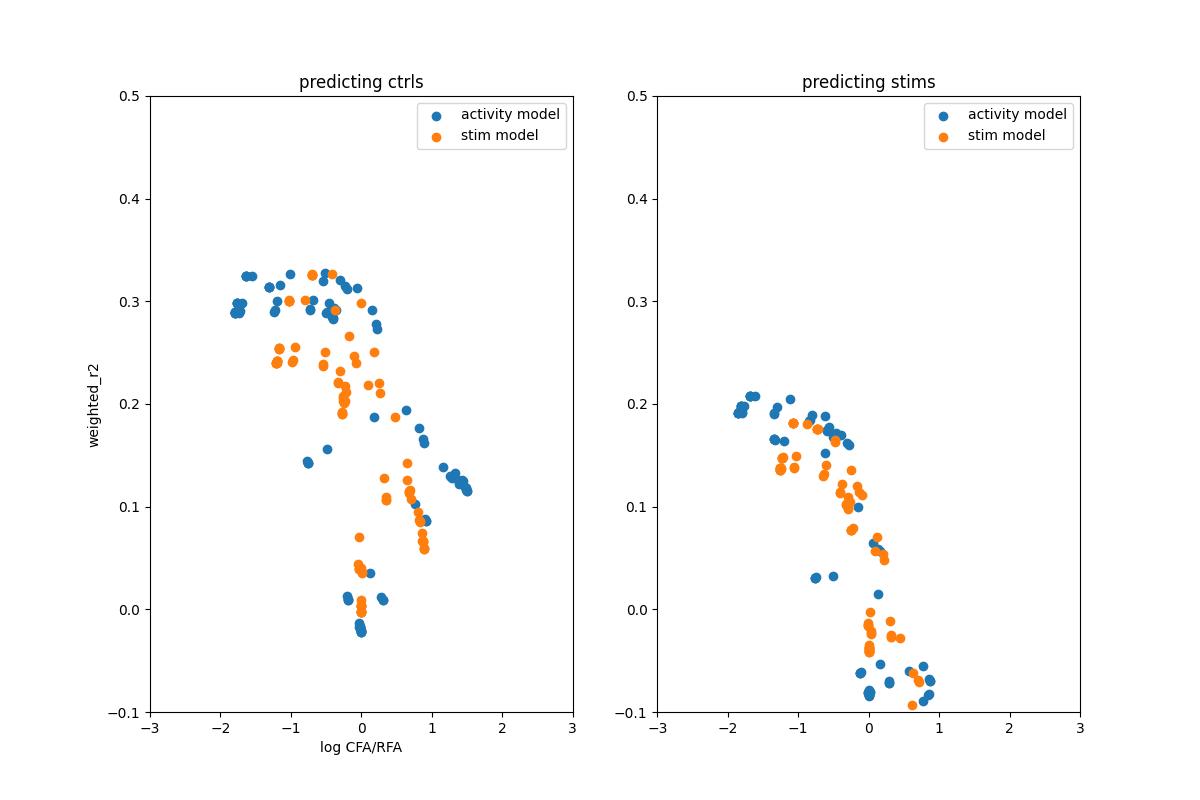

In [105]:
session_num = 0
fig, ax = plt.subplots(figsize=(4,6), ncols=2)
ax[0].scatter(session_iratios[session_num,:,0], session_cr2s[session_num], color='tab:blue', label='activity model')
ax[0].scatter(session_sw_iratios[session_num,:,0], session_sw_cr2s[session_num], color='tab:orange', label='stim model')
#ax[0].axhline(ctrl_asymps[session_num][0], xmin=.5,color='tab:blue', linestyle='--', label='CFA-only')
#ax[0].axhline(ctrl_asymps[session_num][1], xmax=.5,color='tab:red', linestyle='--', label='RFA-only')
ax[0].set_xlim(-3,3)
ax[0].set_ylim(-.1, .5)
ax[0].set_title('predicting ctrls')
ax[0].set_ylabel('weighted_r2')
ax[0].set_xlabel('log CFA/RFA')
ax[0].legend()

ax[1].scatter(session_iratios[session_num,:,1], session_lr2s[session_num], color='tab:blue', label='activity model')
ax[1].scatter(session_sw_iratios[session_num,:,1], session_sw_lr2s[session_num], color='tab:orange', label='stim model')
ax[1].set_title('predicting stims')
ax[1].set_xlim(-3,3)
ax[1].legend()
ax[1].set_ylim(-.1, .5)

fig.set_figheight(8)
fig.set_figwidth(12)

In [21]:
output = pload('../picklejar/bulkSweepRegsSW_10nlag_50post.pickle')
asymps = pload('../picklejar/bulkSweepRegsSWasymps_10nlag_50post.pickle')
session_path = '../data/co/co9/co9_12122023'
session = MPOptoClass(session_path)

love


# inactivate CFA, predict RFA, top 20 PCs

In [22]:
session_lr2s = []
session_cr2s=[]

session_sw_lr2s = []
session_sw_cr2s=[]


session_ratios=[]
session_sw_ratios=[]

session_iratios = []
session_sw_iratios = []

laser_asymps = []
ctrl_asymps = []
for idx, this_session in enumerate(output): 
    if this_session==0:
        continue
    if this_session[0][3] == 'rfa':
        continue
    run_lr2s=[]
    run_cr2s=[]
    run_ratios=[]
    run_iratios = []

    run_sw_lr2s=[]
    run_sw_cr2s=[]
    run_sw_ratios=[]
    run_sw_iratios=[]
    for run in this_session:
        
        h=run[0][0]
        run_ratios.append(run[0][1])
        run_iratios.append((run[0][2], run[0][3]))
        run_lr2s.append(run[0][4])
        run_cr2s.append(run[0][5])
        
         
        h_sw=run[1][0]
        run_sw_ratios.append(run[1][1])
        run_sw_iratios.append((run[1][2], run[1][3]))
        run_sw_lr2s.append(run[1][4])
        run_sw_cr2s.append(run[1][5])

        
    session_lr2s.append(run_lr2s)
    session_cr2s.append(run_cr2s)
    session_ratios.append(run_ratios)
    
    session_sw_lr2s.append(run_sw_lr2s)
    session_sw_cr2s.append(run_sw_cr2s)
    session_sw_ratios.append(run_sw_ratios)
    
    session_iratios.append(run_iratios)
    session_sw_iratios.append(run_sw_iratios)
    
    laser_asymps.append((asymps[idx][0][0], asymps[idx][1][0]))
    ctrl_asymps.append((asymps[idx][0][1], asymps[idx][1][1]))

session_iratios = np.array(session_iratios)
session_sw_iratios = np.array(session_sw_iratios)

    

# example session

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


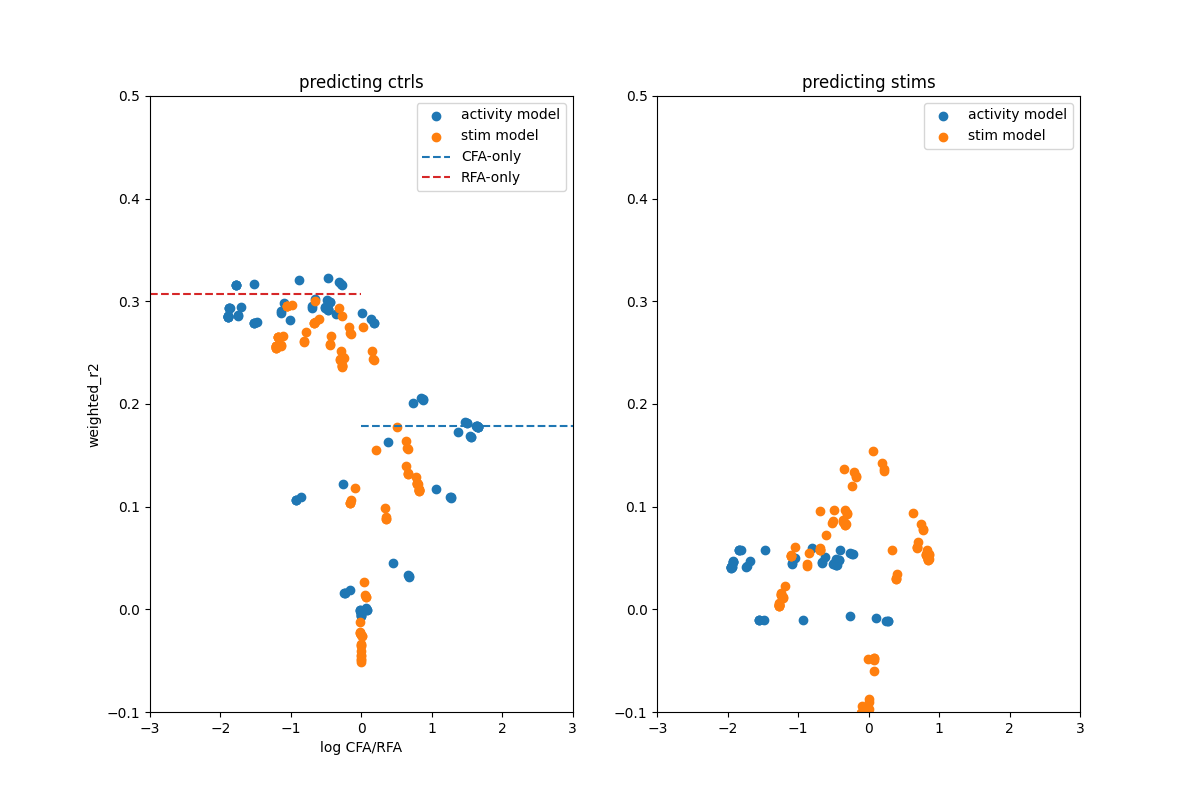

In [23]:
fig, ax = plt.subplots(figsize=(4,6), ncols=2)
#ax[0].scatter(session_ratios[session_num], session_cr2s[session_num], color='tab:blue', label='activity model')
ax[0].scatter(session_iratios[session_num,:,0], session_cr2s[session_num], color='tab:blue', label='activity model')
#ax[0].scatter(session_sw_ratios[session_num], session_sw_cr2s[session_num], color='tab:orange', label='stim model')
ax[0].scatter(session_sw_iratios[session_num,:,0], session_sw_cr2s[session_num], color='tab:orange', label='stim model')
ax[0].axhline(ctrl_asymps[session_num][0], xmin=.5,color='tab:blue', linestyle='--', label='CFA-only')
ax[0].axhline(ctrl_asymps[session_num][1], xmax=.5,color='tab:red', linestyle='--', label='RFA-only')
ax[0].set_xlim(-3,3)
ax[0].set_ylim(-.1, .5)
ax[0].set_title('predicting ctrls')
ax[0].set_ylabel('weighted_r2')
ax[0].set_xlabel('log CFA/RFA')
ax[0].legend()

#ax[1].scatter(session_ratios[session_num], session_lr2s[session_num], color='tab:blue', label='activity model')
ax[1].scatter(session_iratios[session_num,:,1], session_lr2s[session_num], color='tab:blue', label='activity model')
#ax[1].scatter(session_sw_ratios[session_num], session_sw_lr2s[session_num], color='tab:orange', label='stim model')
ax[1].scatter(session_sw_iratios[session_num,:,1], session_sw_lr2s[session_num], color='tab:orange', label='stim model')
ax[1].set_title('predicting stims')
ax[1].set_xlim(-3,3)
ax[1].legend()
ax[1].set_ylim(-.1, .5)

fig.set_figheight(8)
fig.set_figwidth(12)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


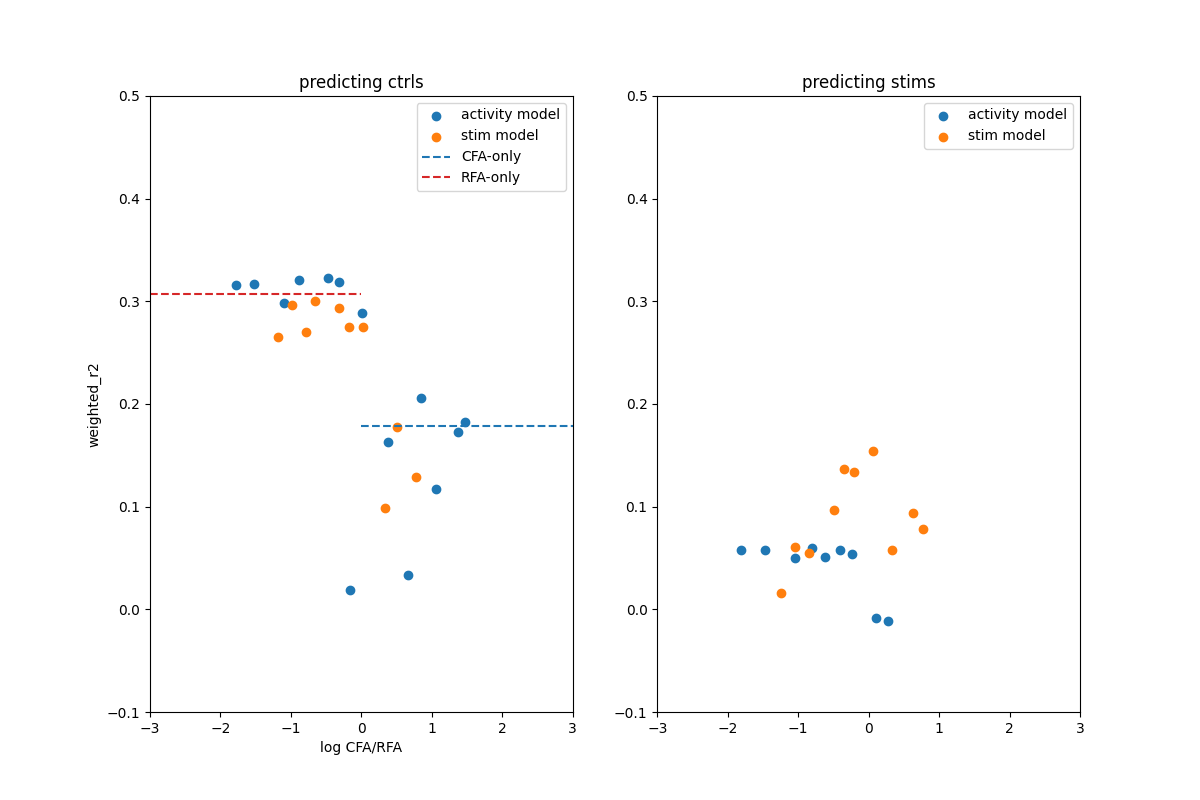

In [24]:
#session_num = 2

#ratio_keep, cr2_keep, edges = get_top_models(np.array(session_ratios[session_num]), np.array(session_cr2s[session_num]))
ratio_keep, cr2_keep, edges = get_top_models(session_iratios[session_num,:,0], np.array(session_cr2s[session_num]))
ratio_sw_keep, cr2_sw_keep, _ = get_top_models(session_sw_iratios[session_num,:,0], np.array(session_sw_cr2s[session_num]), edges=edges)

ratio_lkeep, lr2_keep, edges = get_top_models(session_iratios[session_num,:,1], np.array(session_lr2s[session_num]))
ratio_sw_lkeep, lr2_sw_keep, _ = get_top_models(session_sw_iratios[session_num,:,1], np.array(session_sw_lr2s[session_num]), edges=edges)

fig, ax = plt.subplots(ncols=2)
ax[0].scatter(ratio_keep, cr2_keep, color='tab:blue', label='activity model')
ax[0].scatter(ratio_sw_keep, cr2_sw_keep, color='tab:orange', label='stim model')
ax[0].axhline(ctrl_asymps[session_num][0], xmin=.5,color='tab:blue', linestyle='--', label='CFA-only')
ax[0].axhline(ctrl_asymps[session_num][1], xmax=.5,color='tab:red', linestyle='--', label='RFA-only')
ax[0].set_xlim(-3,3)
ax[0].set_ylim(-.1, .5)
ax[0].set_title('predicting ctrls')
ax[0].set_ylabel('weighted_r2')
ax[0].set_xlabel('log CFA/RFA')
ax[0].legend()

ax[1].scatter(ratio_lkeep, lr2_keep, color='tab:blue', label='activity model')
ax[1].scatter(ratio_sw_lkeep, lr2_sw_keep, color='tab:orange', label='stim model')
ax[1].set_xlim(-3,3)
ax[1].set_ylim(-.1, .5)
ax[1].set_title('predicting stims')
ax[1].legend()

fig.set_figheight(8)
fig.set_figwidth(12)


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


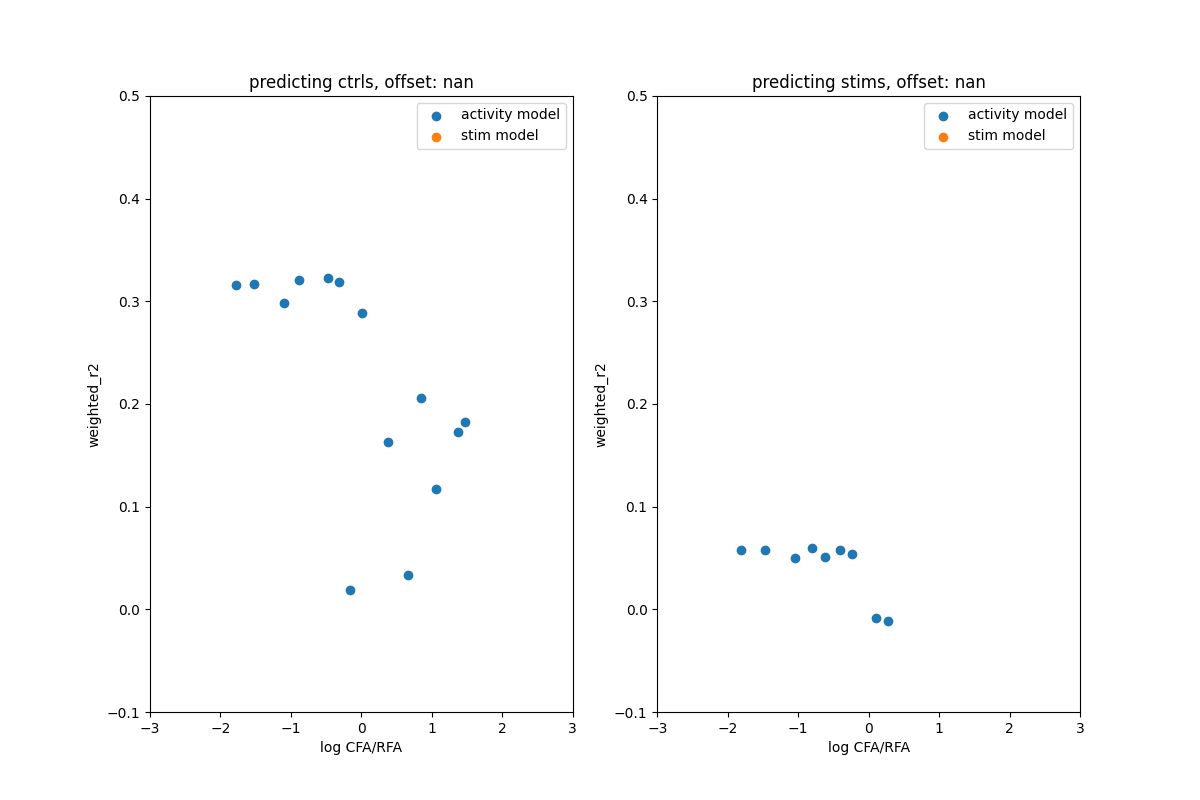

In [25]:
fig1, ax1 = plt.subplots(ncols=2)

#offset=0
offset = np.max(cr2_keep) - np.max(cr2_sw_keep)
ax1[0].scatter(ratio_keep, cr2_keep, label='activity model')
ax1[0].set_xlim(-3,3)
ax1[0].set_ylim(-.1, .5)
ax1[0].set_title('predicting ctrls')
ax1[0].set_ylabel('weighted_r2')
ax1[0].set_xlabel('log CFA/RFA')
ax1[0].scatter(ratio_sw_keep, cr2_sw_keep+offset, label='stim model')
ax1[0].set_title(f'predicting ctrls, offset: {offset}')
ax1[0].legend()

offset =  np.max(lr2_keep)  - np.max(lr2_sw_keep)  
ax1[1].scatter(ratio_lkeep, lr2_keep, label='activity model')
ax1[1].set_xlim(-3,3)
ax1[1].set_ylim(-.1, .5)
ax1[1].set_title('predicting ctrls')
ax1[1].set_ylabel('weighted_r2')
ax1[1].set_xlabel('log CFA/RFA')
ax1[1].scatter(ratio_sw_lkeep, lr2_sw_keep+offset, label='stim model')
ax1[1].set_title(f'predicting stims, offset: {offset}')
ax1[1].legend()

fig1.set_figheight(8)
fig1.set_figwidth(12)

# averaging across all sessions

In [73]:
avg_ratio = []
avg_cr2 = []
avg_lratio = []
avg_lr2 = []

avg_sw_ratio = []
avg_sw_cr2 = []
avg_sw_lratio = []
avg_sw_lr2 = []
for idx in np.arange(len(session_cr2s)):
    ratio_keep, cr2_keep, edges = get_top_models(session_iratios[idx,:,0], np.array(session_cr2s[idx]))
    ratio_sw_keep, cr2_sw_keep, _ = get_top_models(session_sw_iratios[idx,:,0], np.array(session_sw_cr2s[idx]), edges=edges)
    
    avg_ratio.append(ratio_keep)
    avg_cr2.append(cr2_keep)
    avg_sw_ratio.append(ratio_sw_keep)
    avg_sw_cr2.append(cr2_sw_keep)

    ratio_lkeep, lr2_keep, edges = get_top_models(session_iratios[idx,:,1], np.array(session_lr2s[idx]))
    ratio_sw_lkeep, lr2_sw_keep, _ = get_top_models(session_sw_iratios[idx,:,1], np.array(session_sw_lr2s[idx]), edges=edges)
    
        
    avg_lratio.append(ratio_lkeep)
    avg_lr2.append(lr2_keep)
    avg_sw_lratio.append(ratio_sw_lkeep)
    avg_sw_lr2.append(lr2_sw_keep)
    
avg_ratio = nanaverage(avg_ratio, axis=0)
avg_sw_ratio = nanaverage(avg_sw_ratio, axis=0)
avg_lratio = nanaverage(avg_lratio, axis=0)
avg_sw_lratio = nanaverage(avg_sw_lratio, axis=0)

avg_cr2 = nanaverage(avg_cr2, axis=0)
avg_sw_cr2 = nanaverage(avg_sw_cr2, axis=0)
avg_lr2 = nanaverage(avg_lr2, axis=0)
avg_sw_lr2 = nanaverage(avg_sw_lr2, axis=0)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


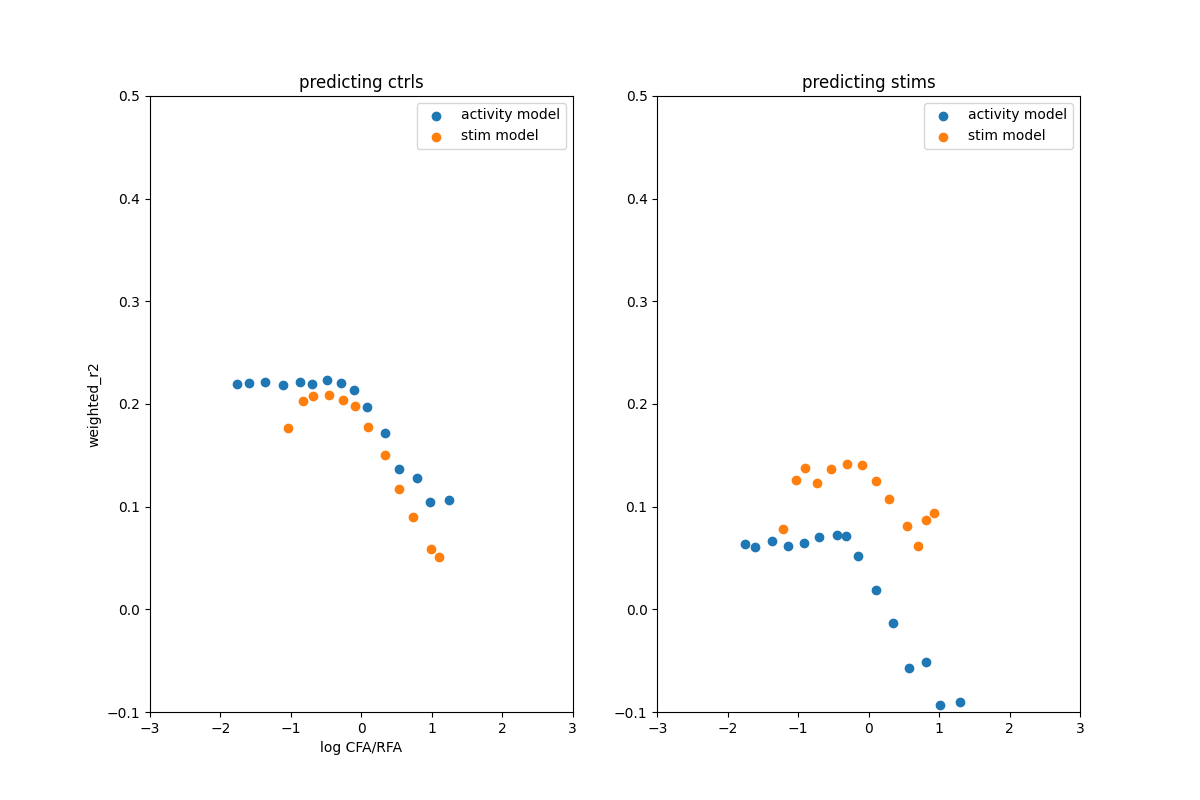

In [75]:
fig, ax = plt.subplots(figsize=(4,6), ncols=2)
ax[0].scatter(avg_ratio, avg_cr2, color='tab:blue', label='activity model')
ax[0].scatter(avg_sw_ratio, avg_sw_cr2, color='tab:orange', label='stim model')
ax[0].set_xlim(-3,3)
ax[0].set_ylim(-.1, .5)
ax[0].set_title('predicting ctrls')
ax[0].set_ylabel('weighted_r2')
ax[0].set_xlabel('log CFA/RFA')
ax[0].legend()

ax[1].scatter(avg_lratio, avg_lr2, color='tab:blue', label='activity model')
ax[1].scatter(avg_sw_lratio, avg_sw_lr2, color='tab:orange', label='stim model')
ax[1].set_title('predicting stims')
ax[1].set_xlim(-3,3)
ax[1].legend()
ax[1].set_ylim(-.1, .5)

fig.set_figheight(8)
fig.set_figwidth(12)